In [2]:
# ===============================
# 1. 이진분류(Binary Classification) 실습
# 예제 데이터 : breast cancer dataset
# 목표 :
# - 이진분류 모델 학습
# - 학습 결과 저장
# - 저장된 모델/스케일러/학습 이력 불러오기
# - 신규 데이터 예측
# - 학습결과 및 예측 결과 시각화
# ================================

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, auc
from sklearn.datasets import load_breast_cancer    # 암진단 데이터 읽어오기

import joblib                                      # 파이썬 객체 저장을 위한 joblib
import tensorflow as tf                            # 텐서플로우 lib

# 케라스의 모델 저장 및 로드 기능을 사용하기 위한 필요 모듈
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

In [12]:
# ================================
# 1. 데이터 읽어오기 (유방암 데이터셋)
# ================================

data = load_breast_cancer()
X = data.data           # 입력 x 데이터
y = data.target         # 타겟 레이블 y 데이터

feature_names = data.feature_names   # 특성 이름
df = pd.DataFrame(X, columns=feature_names)  # 데이터 확인을 데이터프레임으로 변환

df['target'] = y   # 타겟 컬럼을 추가

print('전체 데이터 shape:', df.shape)

전체 데이터 shape: (569, 31)


In [13]:
df.head(10)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0
5,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,0.07613,0.3345,0.8902,2.217,27.19,0.007510,0.03345,0.03672,0.01137,0.02165,0.005082,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,0
6,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,0.05742,0.4467,0.7732,3.180,53.91,0.004314,0.01382,0.02254,0.01039,0.01369,0.002179,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,0
7,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,0.07451,0.5835,1.3770,3.856,50.96,0.008805,0.03029,0.02488,0.01448,0.01486,0.005412,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,0
8,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,0.07389,0.3063,1.0020,2.406,24.32,0.005731,0.03502,0.03553,0.01226,0.02143,0.003749,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,0
9,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,0.08243,0.2976,1.5990,2.039,23.94,0.007149,0.07217,0.07743,0.01432,0.01789,0.010080,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,0


In [14]:
# ================================
# 2. 학습용/테스트용 데이터 분리
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [15]:
# ================================
# 3. 스케일링
# ================================
scaler = StandardScaler()                       # 
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
# ================================
# 4. 모델 정의
# ================================
model = Sequential()                  # 순차형 신경망 모델 생성
model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))   # 첫 번째 은닉층 추가
model.add(Dropout(0.2))                                              # 과적합 방지를 위해 드롭아웃 적용

model.add(Dense(32, activation='relu'))   #두 번째 은닉층 추가
model.add(Dropout(0.2))

model.add(Dense(1, activation='sigmoid'))  #이진분류이므로 출력층 노드 1개의 sigmoid 함수를 사용

model.summary()  # 모델 구조 출력

C:\Users\ui203\anaconda3\envs\aigugbi\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           1,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# ================================
# 5. 모델 컴파일
# ================================

# 손실함수는 binary crossentropy, 평가지표는 accuracy를 사용
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 조기 종료 콜백 정의
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,  # 목표 학습치에 도달하면 조기 종료
)

In [24]:
# ================================
# 6. 모델 학습
# ================================

# 모델을 학습하고, history 객체에 학습 과정을 저장
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5989 - loss: 0.6730 - val_accuracy: 0.9121 - val_loss: 0.4286
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9011 - loss: 0.3720 - val_accuracy: 0.9451 - val_loss: 0.2772
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9258 - loss: 0.2570 - val_accuracy: 0.9451 - val_loss: 0.2021
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9423 - loss: 0.2035 - val_accuracy: 0.9451 - val_loss: 0.1601
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9615 - loss: 0.1537 - val_accuracy: 0.9560 - val_loss: 0.1332
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9588 - loss: 0.1246 - val_accuracy: 0.9560 - val_loss: 0.1177
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9698 - loss: 0.1217 - val_accuracy: 0.9560 - val_loss: 0.1073
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9780 - loss: 0.1060 - val_accuracy: 0.9780 

In [25]:
# ================================
# 7. 모델 평가
# ================================

# 테스트 데이터에 대해 손실과 정확도 평가
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)

# 평가 결과 출력
print('테스트 손실: ', test_loss)
print('테스트 정확도: ', test_acc)

# 예측 확률
y_prob = model.predict(X_test_scaled)

# 확률 0 또는 1 클래스로 변환
y_pred = (y_prob >= 0.5).astype(int).flatten()

# 정확도 계산
acc = accuracy_score(y_test, y_pred)

# confusion_matrix 계산
cm = confusion_matrix(y_test, y_pred)

# 분류 리포트 출력
print('정확도:', acc)
print('confusion matrix: ', cm)
print('분류 리포트: \n', classification_report(y_test, y_pred))

테스트 손실:  0.10624339431524277
테스트 정확도:  0.9649122953414917
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
정확도: 0.9649122807017544
confusion matrix:  [[41  1]
 [ 3 69]]
분류 리포트: 
               precision    recall  f1-score   support

           0       0.93      0.98      0.95        42
           1       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



In [28]:
# ================================
# 8. 학습결과 저장
# ================================

# 모델을 파일로 저장
model.save('Binary_Classification.h5')  # Binary_Classification.keras

# 스케일러를 파일로 저장
joblib.dump(scaler, 'Binary_Classification.pkl')

#학습이력을 데이터프레임으로 변환
history_df = pd.DataFrame(history.history)

# 학습이력을 csv파일로 저장
history_df.to_csv('./results/Binary_Classification.csv', index=False)

# 저장 완료 메세지 출력
print("이진분류 모델, 스케일러, 학습이력 저장 완료")

이진분류 모델, 스케일러, 학습이력 저장 완료


In [30]:
# ================================
# 9. 저장된 결과 읽어오기
# ================================
# 저장된 모델을 다시 불러오기
loaded_model = tf.keras.models.load_model('./results/Binary_Classification.h5')

# 저장된 스케일러를 다시 불러오기
loaded_scaler = joblib.load('./results/Binary_Classification.pkl')

In [32]:
# ================================
# 10. 신규 데이터 예측
# ================================
# 학습하지 않은 테스트데이터 중 첫 5개를 신규 데이터로 예측 수행
new_data = X_test[:5]

# 신규 데이터를 스케일링 처리
new_data_scaled = loaded_scaler.transform(new_data)

# 신규 데이터의 예측 확률 계산
new_prob = loaded_model.predict(new_data_scaled)

# 예측 확률값을 0/1로 변환
new_pred = (new_prob >= 0.5).astype(int).flatten()

# 결과출력
for i in range(len(new_data)):
    print(f"{i+1}번 샘플 - 예측확률: {new_prob[i][0]:.4f}, 예측클래스: {new_pred[i]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1번 샘플 - 예측확률: 0.0000, 예측클래스: 0
2번 샘플 - 예측확률: 1.0000, 예측클래스: 1
3번 샘플 - 예측확률: 0.0000, 예측클래스: 0
4번 샘플 - 예측확률: 0.1053, 예측클래스: 0
5번 샘플 - 예측확률: 0.0000, 예측클래스: 0


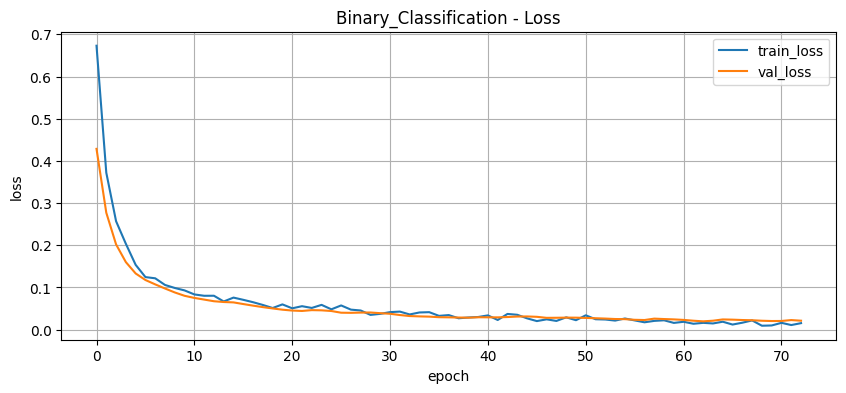

In [33]:
# ================================
# 11. 시각화 결과 확인 (Loss 그래프)
# ================================

# 학습결과 시각화
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Binary_Classification - Loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True)    # 그래프를 격자로 표시
plt.show()

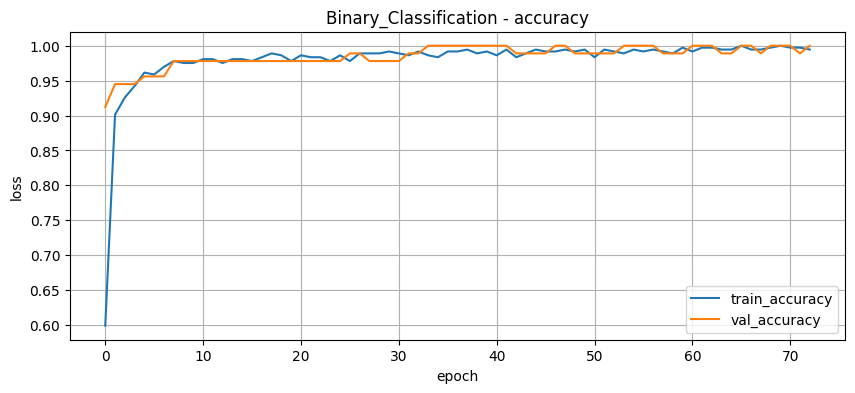

In [34]:
# ================================
# 11-2. 시각화 결과 확인 (정확도 그래프)
# ================================

# 학습 정확도 결과 시각화
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Binary_Classification - accuracy')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True)    # 그래프를 격자로 표시
plt.show()

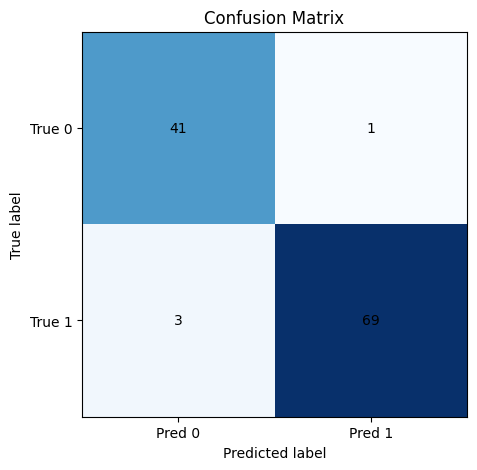

In [36]:
# ================================
# 11-3. 시각화 결과 확인
# ================================

# confusion matrix 시각화
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')

# x축과 y축 눈금 설정
plt.xticks([0,1], ['Pred 0', 'Pred 1'])
plt.yticks([0,1], ['True 0', 'True 1'])

# CM 내부에 숫자 표시
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

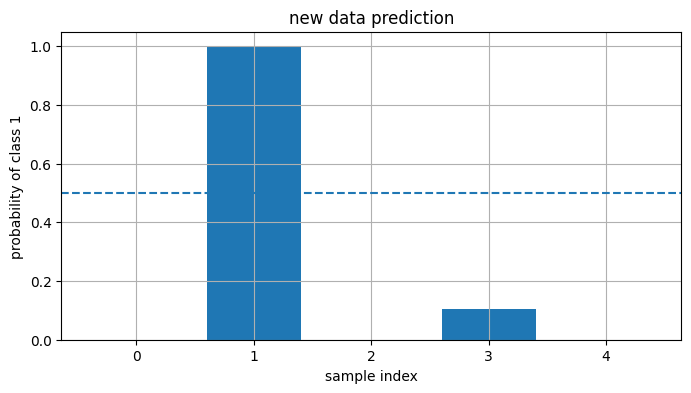

In [38]:
# 신규 데이터 예측 결과 시각화

new_prob_flat = new_prob.flatten()
plt.figure(figsize=(8,4))
plt.bar(range(len(new_prob_flat)), new_prob_flat)

# 기준선 0.5로 표시
plt.axhline(0.5, linestyle="--")

plt.title('new data prediction')
plt.xlabel('sample index')
plt.ylabel('probability of class 1')

plt.grid(True)
plt.show()